# Data Loading

In [ ]:
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
import tensorflow as tf
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
!unzip /content/emo-map-challenge.zip #unzipping the data, requires data to be uploaded to colab first

Archive:  /content/emo-map-challenge.zip
  inflating: test_dataset.csv        
  inflating: train_dataset.csv       


In [ ]:
#Converting Csv files to pd dataframes
train_df=pd.read_csv('train_dataset.csv')
test_df=pd.read_csv('test_dataset.csv')

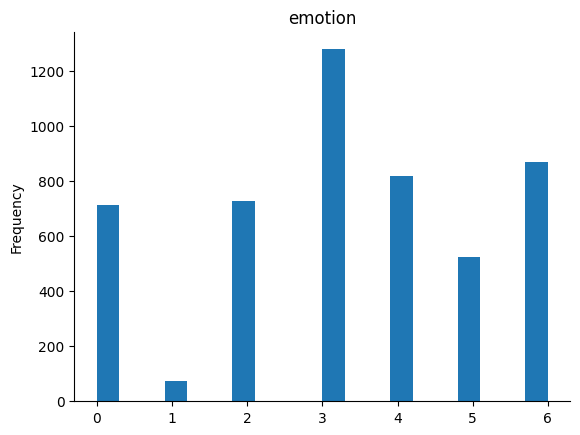

In [ ]:
#checking amount of data per class
from matplotlib import pyplot as plt
train_df['emotion'].plot(kind='hist', bins=20, title='emotion')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
x=train_df['pixels']
y=train_df['emotion']

In [ ]:
#converting to numpy
y=y.to_numpy()

X=x.to_numpy()
for i in range(len(X)):
  X[i] = np.array(X[i].split(), dtype=np.uint8).reshape(48,48)

In [ ]:
X.shape

(5000,)

In [ ]:
#confirming if X is nested array
if isinstance(X[0], np.ndarray):
  print("True")

True


In [ ]:
Xx=np.array([list(i) for i in X]) #converting it into proper format for entering into model

# Data_preprocessing for pre-trained models

In [ ]:
#since given b&w image, convert to 3 channel by repeating
def expand_greyscale_image_channels(grey_image_arr):
    grey_image_arr = np.expand_dims(grey_image_arr, -1)
    grey_image_arr_3_channel = grey_image_arr.repeat(3, axis=-1)
    return grey_image_arr_3_channel

XX=expand_greyscale_image_channels(Xx)

In [ ]:
#performing stratified shuffle split
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.1)
for train_index, valid_index in split.split(XX, y):
    X_train, X_valid = XX[train_index], XX[valid_index]
    y_train, y_valid = y[train_index], y[valid_index]


In [ ]:
# creating tensor prefetch datasets which are easier to enter into models
train_dataset1 = tf.data.Dataset.from_tensor_slices((X_train, y_train))
valid_dataset1 = tf.data.Dataset.from_tensor_slices((X_valid, y_valid))

In [ ]:
batch_size = 48

In [ ]:
# Preprocess the test data while predicting
testy = test_df['pixels'].to_numpy()
for i in range(len(testy)):
  testy[i] = np.array(testy[i].split(), dtype=np.uint8).reshape(48,48)
testy = np.array([list(i) for i in testy])
testy = expand_greyscale_image_channels(testy)
testy = tf.data.Dataset.from_tensor_slices(testy)
testy = testy.map(lambda X: (preprocess(X)))# here the preprocess funcn is different for different models and must be changed accordingly
testy = testy.batch(batch_size)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(factor=0.2, seed=42),  # Rotate up to ±10 degrees
    tf.keras.layers.RandomBrightness(factor=0.2, seed=42),  # Change brightness
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),  # Flip horizontally
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2, seed=42)  # Zoom
])
#performing data augmentation

#Using Pre-Trained Models

In my approach i tried using several pre-trianed model ssuch ass vgg16, vgg19, Xception, Resnet,Mobilenet and others and i tried to change the learning process by altering the learning rates, changing number of iterations in epochs, and using callbacks

# **vgg19**

similar to vgg16 model structure and training implemented

In [ ]:
#creating a preprocess layer for every model
preprocess2 = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.vgg19.preprocess_input)])

In [ ]:
train_dataset1 = train_dataset1.map(lambda X, y: (data_augmentation(X), y))
train_set2 = train_dataset1.map(lambda X, y: (preprocess2(X), y))
train_set2 = train_set2.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set2 = valid_dataset1.map(lambda X, y: (preprocess2(X), y)).batch(batch_size)

In [ ]:
#getting our base pretrained model and creating our model using weights as imagenet
base_model2 = tf.keras.applications.vgg19.VGG19(weights="imagenet",include_top=False)# not including top layers as they use different classes
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model2.output)
x=tf.keras.layers.Dropout(0.5)(avg)#Added to prevent overfitting
output = tf.keras.layers.Dense(7, activation="softmax")(x)
model2 = tf.keras.Model(inputs=base_model2.input, outputs=output)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#freezing all the layers in pre-trained model
for layer in base_model2.layers:
  layer.trainable = False

In [ ]:
#compliling and fitting our model to data
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
model2.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.75, patience=5, min_lr=0.000001)
history = model2.fit(train_set2, validation_data=valid_set2, epochs=20, callbacks=[reduce_lr])

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 79s 553ms/step - accuracy: 0.2027 - loss: 4.5404 - val_accuracy: 0.3280 - val_loss: 1.8755 - learning_rate: 0.0010
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 288ms/step - accuracy: 0.2674 - loss: 2.6815 - val_accuracy: 0.3500 - val_loss: 1.7799 - learning_rate: 0.0010
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 294ms/step - accuracy: 0.2911 - loss: 2.2673 - val_accuracy: 0.3700 - val_loss: 1.6919 - learning_rate: 0.0010
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 283ms/step - accuracy: 0.3303 - loss: 2.0724 - val_accuracy: 0.3880 - val_loss: 1.6613 - learning_rate: 0.0010
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 297ms/step - accuracy: 0.3383 - loss: 1.9799 - val_accuracy: 0.4480 - val_loss: 1.6118 - learning_rate: 0.0010
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 285ms/step - accuracy: 0.3391 - loss: 1.9366 - val_accuracy: 0.3800 - val_loss: 1.6465 - learning_rate: 0.0010
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 321ms/step - accuracy: 0.3451 - loss: 1.

In [ ]:
# The VGG16 model has 19 layers. The range should be (0,18)
for i in range(len(base_model2.layers)):
    print(f"{i:3}: {base_model2.layers[i].name:22}")

  0: input_layer_1         
  1: block1_conv1          
  2: block1_conv2          
  3: block1_pool           
  4: block2_conv1          
  5: block2_conv2          
  6: block2_pool           
  7: block3_conv1          
  8: block3_conv2          
  9: block3_conv3          
 10: block3_conv4          
 11: block3_pool           
 12: block4_conv1          
 13: block4_conv2          
 14: block4_conv3          
 15: block4_conv4          
 16: block4_pool           
 17: block5_conv1          
 18: block5_conv2          
 19: block5_conv3          
 20: block5_conv4          
 21: block5_pool           


=> model has very little data even after augmentation

=> unfreeze very few layers(1 or 2) as number layers is also very little

In [ ]:
#unfreezing very few layers
for layer in base_model2.layers[20:]:
  layer.trainable = True

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9,nesterov=True)
model2.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
#reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.75, patience=4, min_lr=0.000001)
history = model2.fit(train_set2, validation_data=valid_set2, epochs=40)# callbacks=[reduce_lr] can be used

Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 350ms/step - accuracy: 0.3879 - loss: 1.6408 - val_accuracy: 0.4620 - val_loss: 1.4500
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 288ms/step - accuracy: 0.4546 - loss: 1.4596 - val_accuracy: 0.4740 - val_loss: 1.3930
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 287ms/step - accuracy: 0.4734 - loss: 1.3793 - val_accuracy: 0.4840 - val_loss: 1.3738
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 287ms/step - accuracy: 0.5010 - loss: 1.3364 - val_accuracy: 0.4980 - val_loss: 1.3349
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 287ms/step - accuracy: 0.5307 - loss: 1.2933 - val_accuracy: 0.5060 - val_loss: 1.3265
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 286ms/step - accuracy: 0.5376 - loss: 1.2639 - val_accuracy: 0.5220 - val_loss: 1.3064
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 284ms/step - accuracy: 0.5521 - loss: 1.2064 - val_accuracy: 0.5280 - val_loss: 1.2929
Epoch 8/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 287ms/step - accuracy: 0.5573 - loss: 1.1952 - val_accu

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step


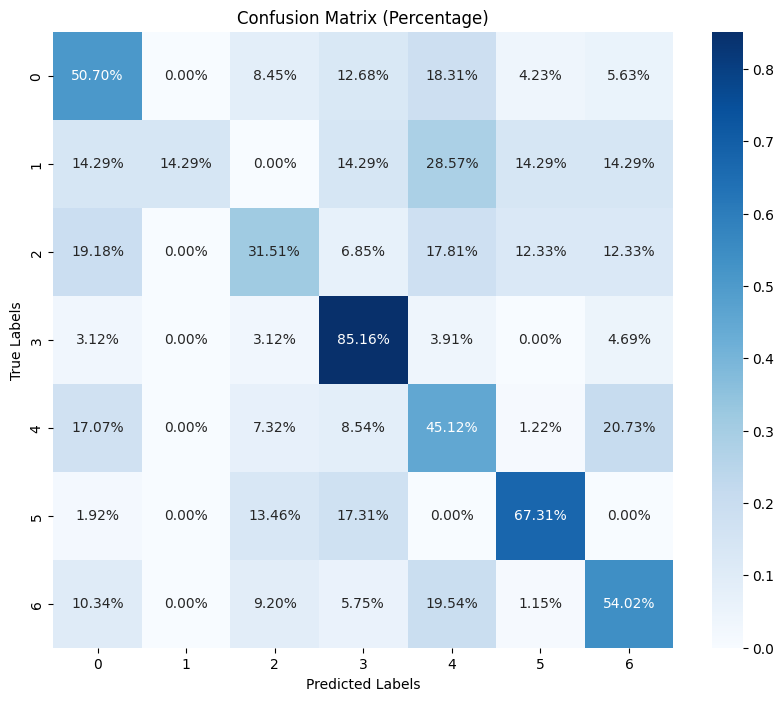

In [ ]:
#predicting on the validation set
y_pred = model2.predict(valid_set2)
y_pred_classes = np.argmax(y_pred, axis=1)
#creating confusion matrix to analyze prediction
cm = confusion_matrix(y_valid, y_pred_classes)

# Normalize for %
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", xticklabels=np.arange(7), yticklabels=np.arange(7))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (Percentage)")
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step
Validation Accuracy per Class:
Class 0: 0.1788
Class 1: 0.0000
Class 2: 0.2162
Class 3: 0.2857
Class 4: 0.2000
Class 5: 0.2368
Class 6: 0.2000


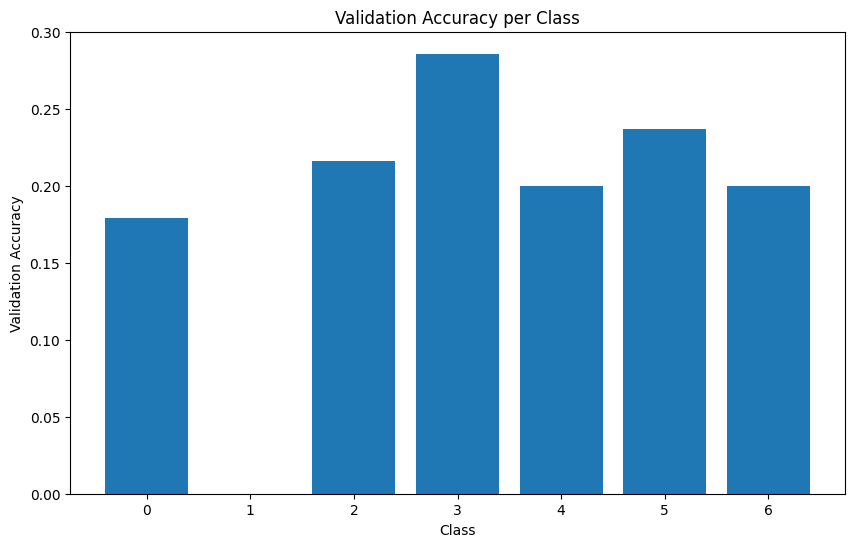

In [ ]:
#classification report to check accuracies
report = classification_report(y_valid, y_pred, output_dict=True)

# validation accuracy for each class
class_accuracies = [report[label]['precision'] for label in report if label.isdigit()] #create a list of precision values from the report dictionary

print("Validation Accuracy per Class:")
for i, acc in enumerate(class_accuracies):
  print(f"Class {i}: {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(range(len(class_accuracies)), class_accuracies)
plt.xlabel("Class")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Class")
plt.xticks(range(len(class_accuracies)))
plt.show()

In [ ]:
# save the above model
model2.save('vgg19ex.keras')

In [ ]:
# Make predictions
predictions = model2.predict(testy)
predicted_labels = np.argmax(predictions, axis=1)

# Create a DataFrame with the predictions
submission_df = pd.DataFrame({'emotion': predicted_labels})
submission_df.index += 5001  # Adjust index to start from 1
submission_df.index.name = 'id'

# Save the predictions to a CSV file
submission_df.to_csv('submission5.csv')


53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step


# NN - XCEPTION model

In [ ]:
#similar preprocessing
preprocess1 = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)])

In [ ]:
train_set = train_dataset1.map(lambda X, y: (data_augmentation(X), y))
train_set1 = train_dataset1.map(lambda X, y: (preprocess1(X), y))
train_set1 = train_set1.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set1 = valid_dataset1.map(lambda X, y: (preprocess1(X), y)).batch(batch_size)

#test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

In [ ]:
#creating our model
base_model1 = tf.keras.applications.xception.Xception(weights="imagenet",include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model1.output)
'''x = tf.keras.layers.Dense(1024, activation='relu')(x)'''#tried using an extra layer before prediction
x = tf.keras.layers.Dropout(0.5)(avg)#Added to prevent overfitting
output = tf.keras.layers.Dense(7, activation="softmax")(x)
model1 = tf.keras.Model(inputs=base_model1.input, outputs=output)

In [ ]:
#freezing basemodel
for layer in base_model1.layers:
  layer.trainable = False

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,nesterov=True)
model1.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
history = model1.fit(train_set1, validation_data=valid_set1, epochs=15, callbacks=[early_stopping_cb])

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 53s 238ms/step - accuracy: 0.3257 - loss: 1.7105 - val_accuracy: 0.3960 - val_loss: 1.5461
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 55s 147ms/step - accuracy: 0.4301 - loss: 1.4948 - val_accuracy: 0.3980 - val_loss: 1.5335
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 145ms/step - accuracy: 0.4473 - loss: 1.4569 - val_accuracy: 0.4340 - val_loss: 1.5196
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 42s 148ms/step - accuracy: 0.4758 - loss: 1.3834 - val_accuracy: 0.4220 - val_loss: 1.4997
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 41s 148ms/step - accuracy: 0.4875 - loss: 1.3613 - val_accuracy: 0.4360 - val_loss: 1.4784
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 152ms/step - accuracy: 0.4870 - loss: 1.3403 - val_accuracy: 0.4680 - val_loss: 1.4632
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - accuracy: 0.5098 - loss: 1.2960 - val_accuracy: 0.4500 - val_loss: 1.4879
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - accuracy: 0.5183 - loss: 1

In [ ]:
#unfreezing from 56th layer
for layer in base_model1.layers[56:]:
  layer.trainable = True

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,nesterov=True)
model1.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
history = model1.fit(train_set1, validation_data=valid_set1, epochs=20)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 73s 374ms/step - accuracy: 0.4023 - loss: 1.6247 - val_accuracy: 0.5100 - val_loss: 1.2959
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 38s 268ms/step - accuracy: 0.7340 - loss: 0.7499 - val_accuracy: 0.5020 - val_loss: 1.5385
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 41s 267ms/step - accuracy: 0.8884 - loss: 0.3404 - val_accuracy: 0.4260 - val_loss: 2.3316
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 41s 267ms/step - accuracy: 0.9099 - loss: 0.2700 - val_accuracy: 0.4840 - val_loss: 2.3394
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 41s 268ms/step - accuracy: 0.9326 - loss: 0.1886 - val_accuracy: 0.5180 - val_loss: 2.4082
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 41s 266ms/step - accuracy: 0.9513 - loss: 0.1468 - val_accuracy: 0.5660 - val_loss: 2.4332
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 41s 268ms/step - accuracy: 0.9658 - loss: 0.1120 - val_accuracy: 0.5700 - val_loss: 2.4906
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 38s 266ms/step - accuracy: 0.9809 - loss: 0

In [ ]:
#create submission using similar form used above

for almost all the models i found that the best optimizer is sgd with nesterov set as True as it ocnverges faster except for mobilenet

In [ ]:
#callbacks i tried using
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,save_weights_only=True,monitor='val_accuracy',mode='max',save_best_only=True)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=15, monitor='val_accuracy', restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy',factor=0.5,patience=5,min_lr=1e-6,verbose=1)

#Densenet model

In [ ]:
preprocess2 = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.densenet.preprocess_input)])

In [ ]:
#here i didnt use augmentation as above because it reduced validaiton accuracy
train_set2 = train_dataset1.map(lambda X, y: (preprocess2(X), y))
train_set2 = train_set2.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set2 = valid_dataset1.map(lambda X, y: (preprocess2(X), y)).batch(batch_size)

In [ ]:
#creating model
base_model2 = tf.keras.applications.densenet.DenseNet121(weights="imagenet",include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model2.output)
x=tf.keras.layers.Dropout(0.5)(avg)#Added to prevent overfitting
output = tf.keras.layers.Dense(7, activation="softmax")(x)
model2 = tf.keras.Model(inputs=base_model2.input, outputs=output)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model2.layers:
  layer.trainable = False

In [ ]:
#checking all the layers in pre-trained model
for i in range(len(base_model2.layers)):
    print(f"{i:3}: {base_model2.layers[i].name:22}")

  0: input_layer_1         
  1: zero_padding2d        
  2: conv1_conv            
  3: conv1_bn              
  4: conv1_relu            
  5: zero_padding2d_1      
  6: pool1                 
  7: conv2_block1_0_bn     
  8: conv2_block1_0_relu   
  9: conv2_block1_1_conv   
 10: conv2_block1_1_bn     
 11: conv2_block1_1_relu   
 12: conv2_block1_2_conv   
 13: conv2_block1_concat   
 14: conv2_block2_0_bn     
 15: conv2_block2_0_relu   
 16: conv2_block2_1_conv   
 17: conv2_block2_1_bn     
 18: conv2_block2_1_relu   
 19: conv2_block2_2_conv   
 20: conv2_block2_concat   
 21: conv2_block3_0_bn     
 22: conv2_block3_0_relu   
 23: conv2_block3_1_conv   
 24: conv2_block3_1_bn     
 25: conv2_block3_1_relu   
 26: conv2_block3_2_conv   
 27: conv2_block3_concat   
 28: conv2_block4_0_bn     
 29: conv2_block4_0_relu   
 30: conv2_block4_1_conv   
 31: conv2_block4_1_bn     
 32: conv2_block4_1_relu   
 33: conv2_block4_2_conv   
 34: conv2_block4_concat   
 35: conv2_block5_0_

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=0.000001)
model2.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
history = model2.fit(train_set2, validation_data=valid_set2, epochs=50,callbacks=[reduce_lr])

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 80s 686ms/step - accuracy: 0.2213 - loss: 2.0476 - val_accuracy: 0.3340 - val_loss: 1.6884 - learning_rate: 0.0010
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 32s 234ms/step - accuracy: 0.3360 - loss: 1.6860 - val_accuracy: 0.3780 - val_loss: 1.5816 - learning_rate: 0.0010
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 231ms/step - accuracy: 0.3755 - loss: 1.6078 - val_accuracy: 0.4000 - val_loss: 1.5428 - learning_rate: 0.0010
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.4041 - loss: 1.5548 - val_accuracy: 0.4120 - val_loss: 1.5120 - learning_rate: 0.0010
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step - accuracy: 0.4058 - loss: 1.5232 - val_accuracy: 0.4020 - val_loss: 1.4980 - learning_rate: 0.0010
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - accuracy: 0.4277 - loss: 1.4952 - val_accuracy: 0.4380 - val_loss: 1.4769 - learning_rate: 0.0010
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 212ms/step - accuracy: 0.4226 - loss: 1.


KeyboardInterrupt



In [ ]:
for layer in base_model2.layers[411:]:
  layer.trainable = True

In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: weight for i, weight in enumerate(class_weights)} # Convert to dictionary

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9,nesterov=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=0.000001)
model2.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
history = model2.fit(train_set2, validation_data=valid_set2, epochs=50,callbacks=[reduce_lr])

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 60s 506ms/step - accuracy: 0.7909 - loss: 0.5540 - val_accuracy: 0.5220 - val_loss: 1.5704 - learning_rate: 1.0000e-04
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 54s 217ms/step - accuracy: 0.8052 - loss: 0.5419 - val_accuracy: 0.5200 - val_loss: 1.5637 - learning_rate: 1.0000e-04
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step - accuracy: 0.8075 - loss: 0.5455 - val_accuracy: 0.5220 - val_loss: 1.5668 - learning_rate: 1.0000e-04
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 234ms/step - accuracy: 0.7992 - loss: 0.5437 - val_accuracy: 0.5220 - val_loss: 1.5696 - learning_rate: 1.0000e-04
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 212ms/step - accuracy: 0.8041 - loss: 0.5364 - val_accuracy: 0.5200 - val_loss: 1.5708 - learning_rate: 1.0000e-04
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - accuracy: 0.8024 - loss: 0.5400 - val_accuracy: 0.5200 - val_loss: 1.5714 - learning_rate: 1.0000e-04
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 228ms/step - acc

KeyboardInterrupt: 

In [ ]:
#here i interrupted code as i could see that our model stagnated on the validation accuracy

16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 481ms/step


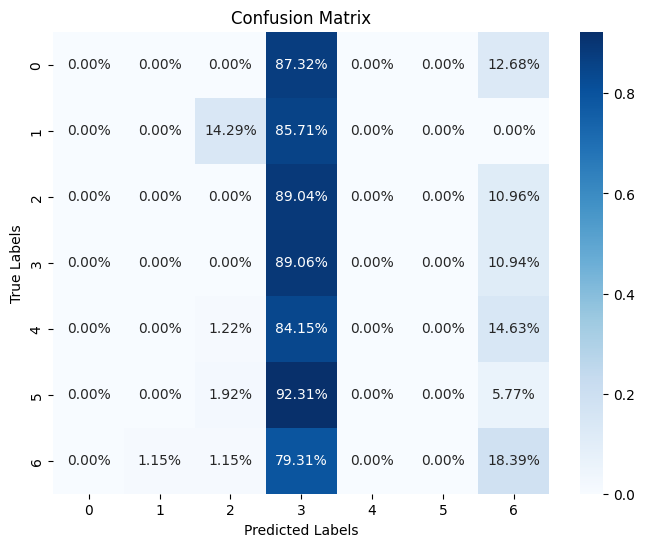

In [ ]:
y_pred = model2.predict(X_valid)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_valid

cm = confusion_matrix(y_true, y_pred_classes, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", xticklabels=np.arange(7), yticklabels=np.arange(7))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

we can see the above model is classifying only on classes 3 and 6.
this might be due to the high number of training data in classes 3 and 6 and also the large number of layers unfrozen, leading to potential overfitting.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Validation Accuracy per Class:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 0.0000
Class 3: 0.2633
Class 4: 0.0000
Class 5: 0.0000
Class 6: 0.2581


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


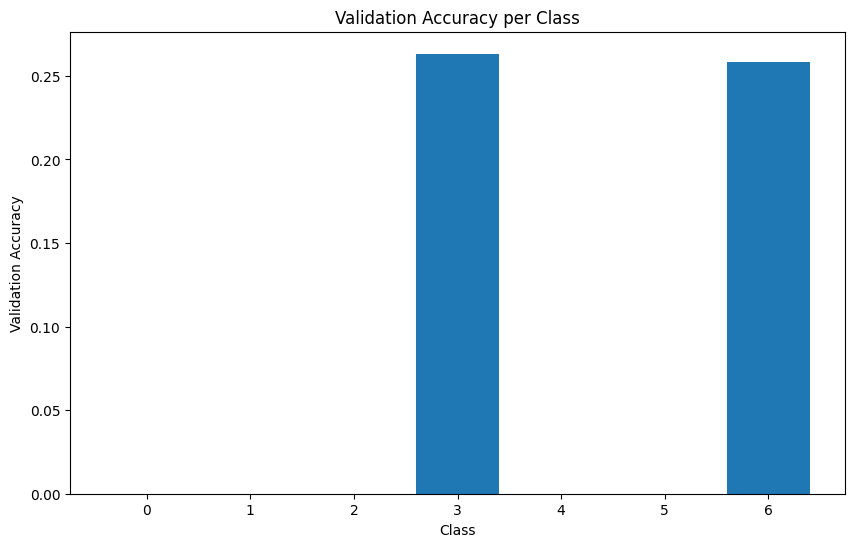

In [ ]:
#classification report
report = classification_report(y_valid, y_pred, output_dict=True)
class_accuracies = [report[label]['precision'] for label in report if label.isdigit()] #create a list of precision values from the report dictionary
#validation accuracy for each class
print("Validation Accuracy per Class:")
for i, acc in enumerate(class_accuracies):
  print(f"Class {i}: {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(range(len(class_accuracies)), class_accuracies)
plt.xlabel("Class")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Class")
plt.xticks(range(len(class_accuracies)))
plt.show()

In [ ]:
#possible remedies might be to evenly augment data so that all classes have equal data
#potentially reduce number of layers unfrozen and use early stopping callback

# using resnet

In [ ]:
preprocess3 = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input)])

In [ ]:
train_dataset1 = train_dataset1.map(lambda X, y: (data_augmentation(X), y))
train_set3 = train_dataset1.map(lambda X, y: (preprocess3(X), y))
train_set3 = train_set3.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set3 = valid_dataset1.map(lambda X, y: (preprocess3(X), y)).batch(batch_size)
#test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

In [ ]:
base_model3 = tf.keras.applications.resnet50.ResNet50(weights="imagenet",include_top=False)

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model3.output)
x = tf.keras.layers.Dense(1024, activation="relu")(avg)
x=tf.keras.layers.Dropout(0.6)(x)#Added to prevent overfitting
output = tf.keras.layers.Dense(7, activation="softmax")(x)
model3 = tf.keras.Model(inputs=base_model3.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model3.layers:
  layer.trainable = False

In [ ]:
base_model3.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, None, None, 3)  │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, None, None, 3)  │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, None, None, 64) │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, None, None, 64) │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, None, None, 64) │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, None, None, 64) │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, None, None, 64) │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, None, None, 64) │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, None, None, 64) │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, None, None, 64) │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, None, None, 64) │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, None, None, 64) │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, None, None, 64) │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, None, None,     │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │ 256)                   │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, None, None,     │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
i=1
for layer in base_model3.layers:
  print(i,layer)
  i+=1

1 <InputLayer name=input_layer_3, built=True>
2 <ZeroPadding2D name=conv1_pad, built=True>
3 <Conv2D name=conv1_conv, built=True>
4 <BatchNormalization name=conv1_bn, built=True>
5 <Activation name=conv1_relu, built=True>
6 <ZeroPadding2D name=pool1_pad, built=True>
7 <MaxPooling2D name=pool1_pool, built=True>
8 <Conv2D name=conv2_block1_1_conv, built=True>
9 <BatchNormalization name=conv2_block1_1_bn, built=True>
10 <Activation name=conv2_block1_1_relu, built=True>
11 <Conv2D name=conv2_block1_2_conv, built=True>
12 <BatchNormalization name=conv2_block1_2_bn, built=True>
13 <Activation name=conv2_block1_2_relu, built=True>
14 <Conv2D name=conv2_block1_0_conv, built=True>
15 <Conv2D name=conv2_block1_3_conv, built=True>
16 <BatchNormalization name=conv2_block1_0_bn, built=True>
17 <BatchNormalization name=conv2_block1_3_bn, built=True>
18 <Add name=conv2_block1_add, built=True>
19 <Activation name=conv2_block1_out, built=True>
20 <Conv2D name=conv2_block2_1_conv, built=True>
21 <BatchN

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,nesterov=True)
model3.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
history = model3.fit(train_set3, validation_data=valid_set3, epochs=23, batch_size=64, callbacks=[early_stopping_cb])

Epoch 1/23
71/71 ━━━━━━━━━━━━━━━━━━━━ 56s 544ms/step - accuracy: 0.2064 - loss: 3.8806 - val_accuracy: 0.3160 - val_loss: 2.7570
Epoch 2/23
71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 342ms/step - accuracy: 0.2573 - loss: 3.7125 - val_accuracy: 0.3720 - val_loss: 2.1069
Epoch 3/23
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 346ms/step - accuracy: 0.3074 - loss: 3.3845 - val_accuracy: 0.3660 - val_loss: 2.2712
Epoch 4/23
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 356ms/step - accuracy: 0.2848 - loss: 3.5915 - val_accuracy: 0.3800 - val_loss: 2.3872
Epoch 5/23
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 341ms/step - accuracy: 0.2984 - loss: 3.4364 - val_accuracy: 0.3920 - val_loss: 2.5457
Epoch 6/23
71/71 ━━━━━━━━━━━━━━━━━━━━ 43s 350ms/step - accuracy: 0.2967 - loss: 3.4851 - val_accuracy: 0.3940 - val_loss: 2.3847
Epoch 7/23
71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 327ms/step - accuracy: 0.2912 - loss: 3.5367 - val_accuracy: 0.3720 - val_loss: 3.1062
Epoch 8/23
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 329ms/step - accuracy: 0.2861 - loss: 3.7488 - val_accu

In [ ]:
for layer in base_model3.layers[160:]:
  layer.trainable = True

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9, nesterov=True)
model3.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
history = model3.fit(train_set3, validation_data=valid_set3, epochs=50, batch_size=48, callbacks=[early_stopping_cb])
#reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=3, min_lr=0.000001)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 55s 481ms/step - accuracy: 0.3036 - loss: 2.8301 - val_accuracy: 0.3840 - val_loss: 1.8572
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 348ms/step - accuracy: 0.3248 - loss: 2.5397 - val_accuracy: 0.4160 - val_loss: 1.7628
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 349ms/step - accuracy: 0.3411 - loss: 2.3687 - val_accuracy: 0.4200 - val_loss: 1.7094
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 350ms/step - accuracy: 0.3330 - loss: 2.4087 - val_accuracy: 0.4240 - val_loss: 1.6872
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 357ms/step - accuracy: 0.3304 - loss: 2.3728 - val_accuracy: 0.4280 - val_loss: 1.6840
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 28s 357ms/step - accuracy: 0.3377 - loss: 2.2754 - val_accuracy: 0.4360 - val_loss: 1.6512
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 344ms/step - accuracy: 0.3487 - loss: 2.2236 - val_accuracy: 0.4340 - val_loss: 1.6357
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 349ms/step - accuracy: 0.3494 - loss: 2.2550 - val_accu

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)#increasing learning rate
model3.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
history = model3.fit(train_set3, validation_data=valid_set3, epochs=20)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 93s 207ms/step - accuracy: 0.9998 - loss: 0.0041 - val_accuracy: 0.5460 - val_loss: 2.2409
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.9999 - loss: 0.0051 - val_accuracy: 0.5460 - val_loss: 2.2749
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.9991 - loss: 0.0055 - val_accuracy: 0.5440 - val_loss: 2.2303
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - accuracy: 0.9982 - loss: 0.0090 - val_accuracy: 0.5500 - val_loss: 2.2785
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.9996 - loss: 0.0053 - val_accuracy: 0.5480 - val_loss: 2.3301
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.9987 - loss: 0.0076 - val_accuracy: 0.5420 - val_loss: 2.3820
Epoch 7/20


KeyboardInterrupt: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step


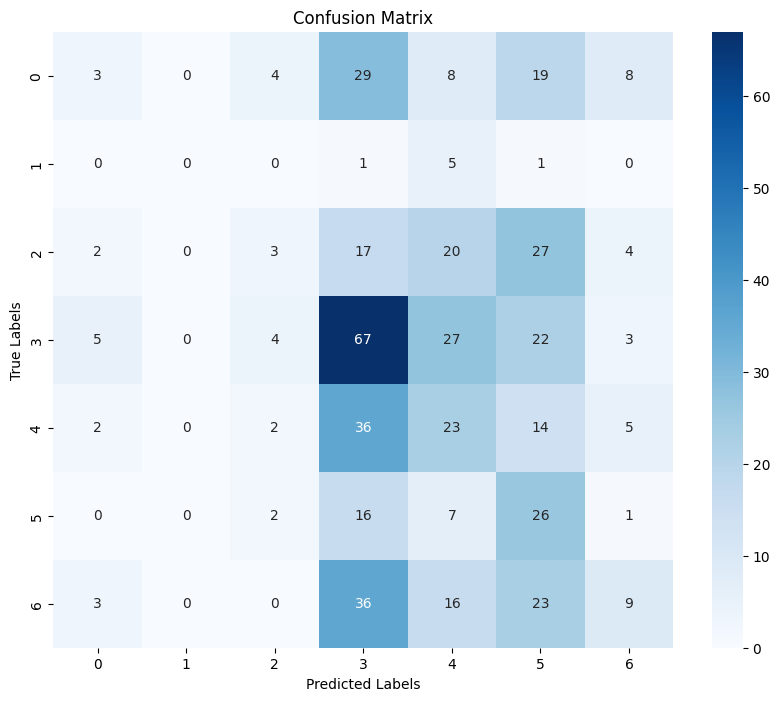

In [ ]:
cm = confusion_matrix(y_valid, y_pred3)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Validation Accuracy per Class:
Class 0: 0.3077
Class 1: 0.0000
Class 2: 0.1980
Class 3: 0.2834
Class 4: 0.2581
Class 5: 0.2381
Class 6: 0.3333


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


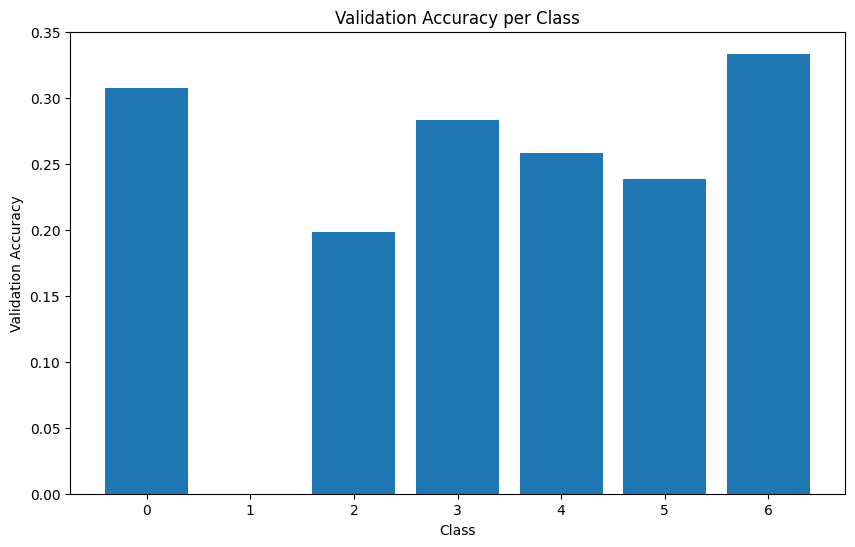

In [ ]:
y_pred = np.argmax(model3.predict(X_valid), axis=1)
#the classification report
report = classification_report(y_valid, y_pred, output_dict=True)
#validation accuracy for each class
class_accuracies = [report[label]['precision'] for label in report if label.isdigit()] #create a list of precision values from the report dictionary

print("Validation Accuracy per Class:")
for i, acc in enumerate(class_accuracies):
  print(f"Class {i}: {acc:.4f}")

# Plot the validation accuracy for each class
plt.figure(figsize=(10, 6))
plt.bar(range(len(class_accuracies)), class_accuracies)
plt.xlabel("Class")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Class")
plt.xticks(range(len(class_accuracies)))
plt.show()

here too we can see that the model is misclassifying lot of classes
one remedy might have been to first train the model on high lr(0.1 or 0.01) for a few epochs before reducing and even using an lr scheduler.

#To try by me in future

1.)Try using vision transformers (ViTs)

2.)Try using ensemble methods such as an svm or mean avergaing ensemble algorithm to try and combine the best performing models to get better accuracy

3.) To try better ways of data augmenting to solve problem of imbalanced dataset

4.)To try simpler approaches from sklearn after extracting features from images

5.)Try automatic hyperparameter tuning using keras tuner

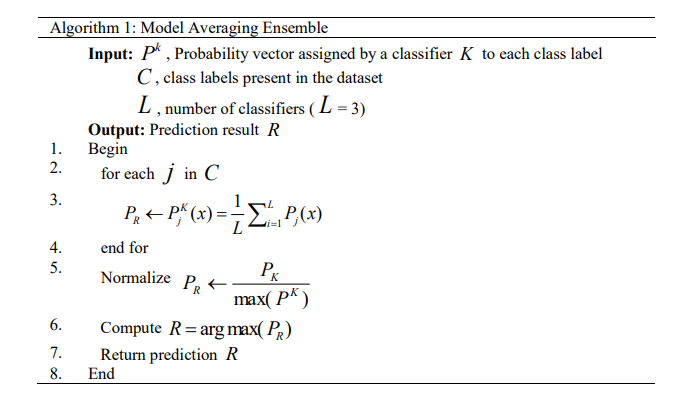

In [ ]:
#above pseudo code is sourced from a research paper i found online